# Option 3: Stock Clustering Analysis

## Objective
Group stocks into clusters based on financial characteristics

## Clustering Methods
- K-Means Clustering (optimized with Elbow Method)
- Hierarchical Clustering
- Analysis of cluster characteristics and risk profiles

## Detailed Plan
1. Prepare clustering features for all available S&P 500 stocks.
2. Standardize features to avoid scale bias.
3. Select cluster count using Elbow, Silhouette, and Davies-Bouldin metrics.
4. Build final K-Means model and generate stock-to-cluster assignments.
5. Validate structure with Hierarchical Clustering (dendrogram).
6. Visualize cluster separation using PCA.
7. Produce cluster profile and risk interpretation for portfolio decisions.
8. Save outputs into task folders: data and graph.

In [9]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn scipy kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist, pdist
from sklearn.metrics import silhouette_score, davies_bouldin_score
import kagglehub, os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

cwd = Path.cwd()
TASK_FOLDER = '03_stock_clustering_analysis'
if cwd.name == 'implementation':
    task_root = cwd.parent
elif cwd.name == TASK_FOLDER:
    task_root = cwd
elif (cwd / TASK_FOLDER).exists():
    task_root = cwd / TASK_FOLDER
else:
    task_root = cwd

DATA_DIR = task_root / 'data'
GRAPH_DIR = task_root / 'graph'
DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("✓ All libraries loaded successfully")
print(f"✓ Data folder: {DATA_DIR}")
print(f"✓ Graph folder: {GRAPH_DIR}")

Note: you may need to restart the kernel to use updated packages.
✓ All libraries loaded successfully
✓ Data folder: \\compdrive\Student5\25012923g\COMProfile\Desktop\Machine Learning project\project_folder\03_stock_clustering_analysis\data
✓ Graph folder: \\compdrive\Student5\25012923g\COMProfile\Desktop\Machine Learning project\project_folder\03_stock_clustering_analysis\graph



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1: Data Loading & Selection

In [10]:
# Download S&P 500 dataset
path = kagglehub.dataset_download("camnugent/sandp500")
files = os.listdir(path)
csv_file = [f for f in files if f.endswith(".csv")][0]
data = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset Shape: {data.shape}")
print(f"Unique stocks: {data['Name'].nunique()}")
print(f"Date Range: {data['date'].min()} to {data['date'].max()}")

# Get latest data for each stock
latest_data = data.sort_values('date').drop_duplicates('Name', keep='last')
print(f"\nStocks in dataset: {len(latest_data)}")

Dataset Shape: (619040, 7)
Unique stocks: 505
Date Range: 2013-02-08 to 2018-02-07

Stocks in dataset: 505


## Step 2: Feature Engineering for Clustering

In [11]:
def create_clustering_features(stock_data):
    """Create features for stock clustering"""
    stock_data = stock_data.sort_values('date').reset_index(drop=True)
    
    # Volatility - standard deviation of returns
    stock_data['volatility'] = stock_data['close'].pct_change().rolling(20).std()
    
    # Average returns
    stock_data['avg_return'] = stock_data['close'].pct_change().rolling(20).mean()
    
    # Trading volume characteristics
    stock_data['avg_volume'] = stock_data['volume'].rolling(20).mean()
    stock_data['volume_volatility'] = stock_data['volume'].rolling(20).std() / stock_data['volume'].rolling(20).mean()
    
    # Price momentum
    stock_data['momentum'] = (stock_data['close'] - stock_data['close'].shift(20)) / stock_data['close'].shift(20)
    
    # Price range (high-low spread)
    stock_data['price_range'] = (stock_data['high'] - stock_data['low']) / stock_data['close']
    
    # Trend strength (higher close vs low)
    stock_data['trend_strength'] = (stock_data['close'] - stock_data['low']) / (stock_data['high'] - stock_data['low'])
    
    # Price level (normalized by 100s)
    stock_data['price_level'] = stock_data['close'] / 100
    
    # Beta-like volatility vs overall market
    stock_data['volume_to_price_ratio'] = stock_data['volume'] / stock_data['close']
    
    return stock_data

# Apply feature engineering to all stocks
data_processed = pd.concat([create_clustering_features(data[data['Name'] == stock]) 
                            for stock in data['Name'].unique()], ignore_index=True)

# Get latest record for each stock
clustering_data = data_processed.sort_values('date').drop_duplicates('Name', keep='last')
clustering_data = clustering_data.dropna()

print(f"Stocks with complete features: {len(clustering_data)}")
print(f"\nFeature Statistics:")
print(clustering_data[['volatility', 'avg_return', 'momentum', 'price_level']].describe().round(4))

Stocks with complete features: 505

Feature Statistics:
       volatility  avg_return  momentum  price_level
count    505.0000    505.0000  505.0000     505.0000
mean       0.0182     -0.0015   -0.0312       1.0776
std        0.0064      0.0034    0.0652       1.4032
min        0.0066     -0.0162   -0.2864       0.0289
25%        0.0141     -0.0034   -0.0714       0.4786
50%        0.0170     -0.0017   -0.0351       0.7538
75%        0.0207      0.0006    0.0093       1.1983
max        0.0574      0.0123    0.2640      18.8268


## Step 3: Data Preparation & Scaling

In [12]:
# Select features for clustering
feature_cols = [
    'volatility', 'avg_return', 'avg_volume', 'volume_volatility',
    'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio'
]

X = clustering_data[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

stock_names = clustering_data['Name'].values

print(f'Clustering samples: {X_scaled.shape[0]}')
print(f'Features used ({len(feature_cols)}): {feature_cols}')
print(f'Output folders ready: {DATA_DIR}, {GRAPH_DIR}')

Clustering samples: 505
Features used (9): ['volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio']
Output folders ready: \\compdrive\Student5\25012923g\COMProfile\Desktop\Machine Learning project\project_folder\03_stock_clustering_analysis\data, \\compdrive\Student5\25012923g\COMProfile\Desktop\Machine Learning project\project_folder\03_stock_clustering_analysis\graph


## Step 4: Find Optimal Number of Clusters (Elbow + Silhouette + Davies-Bouldin)

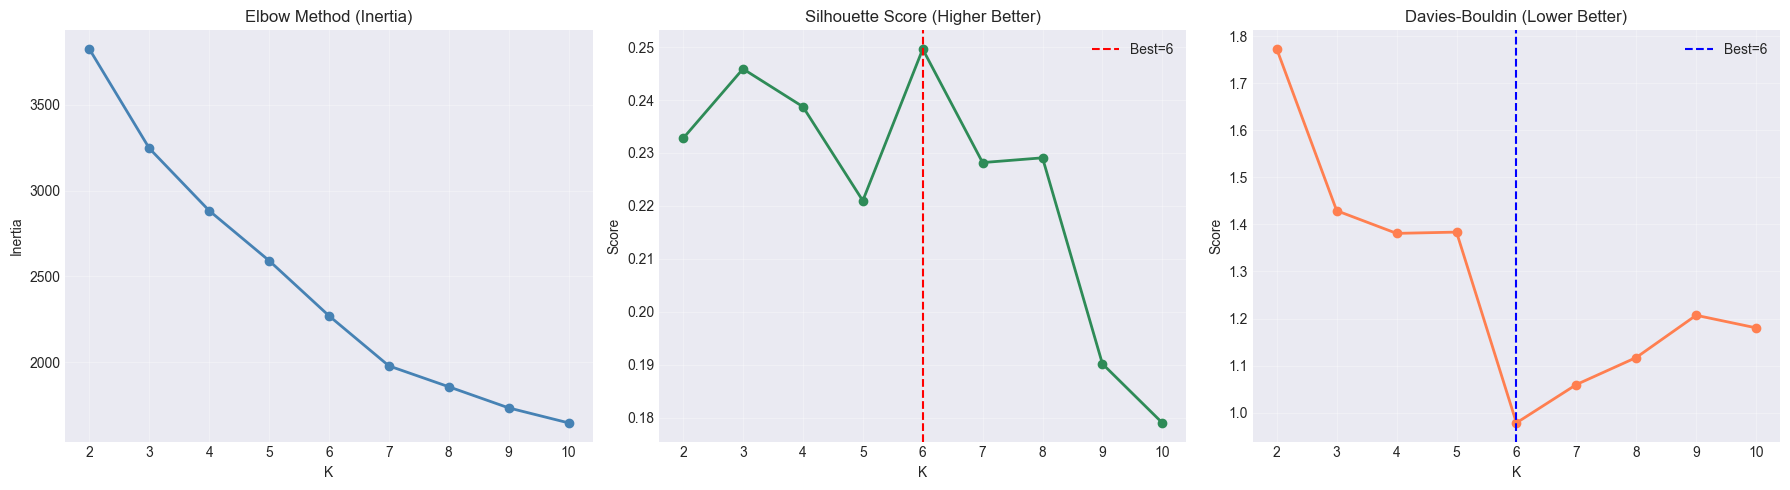

Best K by Silhouette: 6
Best K by Davies-Bouldin: 6
Chosen K for final model: 6


In [13]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []
db_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

best_k_sil = list(k_values)[int(np.argmax(silhouette_scores))]
best_k_db = list(k_values)[int(np.argmin(db_scores))]
optimal_k = best_k_sil

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(k_values), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_values), silhouette_scores, 'o-', color='seagreen', linewidth=2)
axes[1].axvline(best_k_sil, color='red', linestyle='--', label=f'Best={best_k_sil}')
axes[1].set_title('Silhouette Score (Higher Better)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(list(k_values), db_scores, 'o-', color='coral', linewidth=2)
axes[2].axvline(best_k_db, color='blue', linestyle='--', label=f'Best={best_k_db}')
axes[2].set_title('Davies-Bouldin (Lower Better)')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/01_optimal_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Best K by Silhouette: {best_k_sil}')
print(f'Best K by Davies-Bouldin: {best_k_db}')
print(f'Chosen K for final model: {optimal_k}')

## Step 5: Final K-Means Clustering and Cluster Summary

In [14]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clustering_data['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_sizes = clustering_data['cluster'].value_counts().sort_index()
print('Cluster size distribution:')
for c, n in cluster_sizes.items():
    print(f'  Cluster {c}: {n} stocks ({n/len(clustering_data)*100:.1f}%)')

sil = silhouette_score(X_scaled, clustering_data['cluster'])
dbi = davies_bouldin_score(X_scaled, clustering_data['cluster'])
print(f'\nFinal silhouette score: {sil:.4f}')
print(f'Final Davies-Bouldin score: {dbi:.4f}')

cluster_summary = clustering_data.groupby('cluster')[feature_cols].mean().round(4)
display(cluster_summary)

cluster_summary.to_csv(f'{DATA_DIR}/cluster_feature_summary.csv')
clustering_data[['Name','cluster'] + feature_cols].to_csv(
    f'{DATA_DIR}/stock_cluster_assignments.csv', index=False
)
print('\nSaved CSV: cluster_feature_summary.csv, stock_cluster_assignments.csv')

Cluster size distribution:
  Cluster 0: 286 stocks (56.6%)
  Cluster 1: 139 stocks (27.5%)
  Cluster 2: 4 stocks (0.8%)
  Cluster 3: 1 stocks (0.2%)
  Cluster 4: 71 stocks (14.1%)
  Cluster 5: 4 stocks (0.8%)

Final silhouette score: 0.2496
Final Davies-Bouldin score: 0.9782


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0154,-0.0021,3.768906e+06,0.3594,-0.0433,0.0253,0.1739,1.0233,7.397786e+04
1,0.0208,0.0021,4.968325e+06,0.4488,0.0383,0.0345,0.4760,1.0404,1.257531e+05
2,0.0249,-0.0044,8.231132e+07,0.4276,-0.0855,0.0273,0.2022,0.1722,4.838050e+06
3,0.0327,-0.0162,3.924752e+07,0.3542,-0.2864,0.1246,0.2500,0.0289,2.462799e+07
4,0.0240,-0.0058,5.580841e+06,0.5299,-0.1143,0.0413,0.2162,0.7349,2.046012e+05
5,0.0179,0.0005,2.729800e+06,0.4238,0.0092,0.0321,0.1980,13.5086,2.509195e+03



Saved CSV: cluster_feature_summary.csv, stock_cluster_assignments.csv


## Step 6: PCA Visualization and Hierarchical Clustering Dendrogram

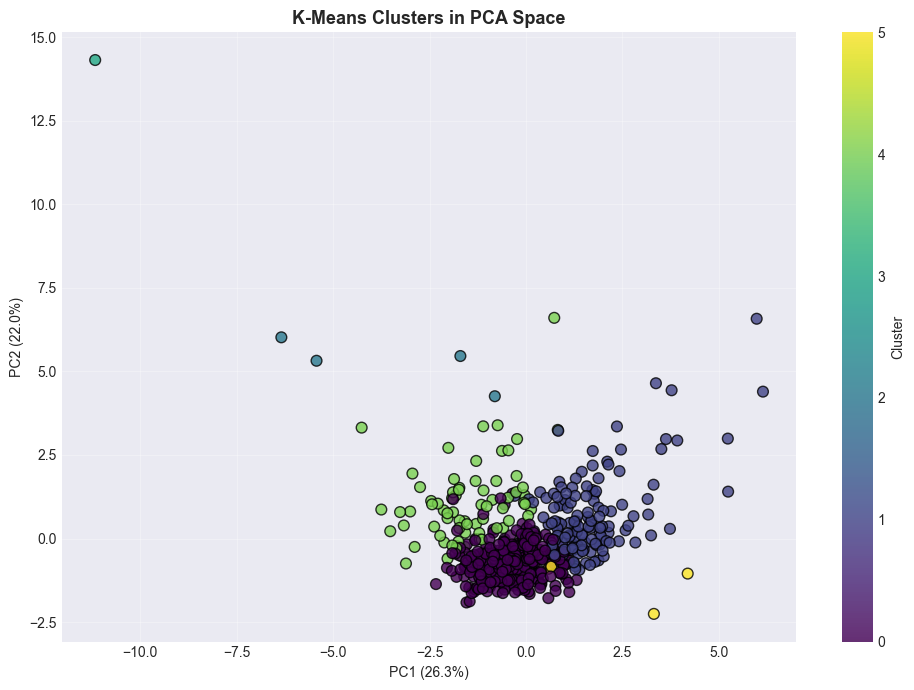

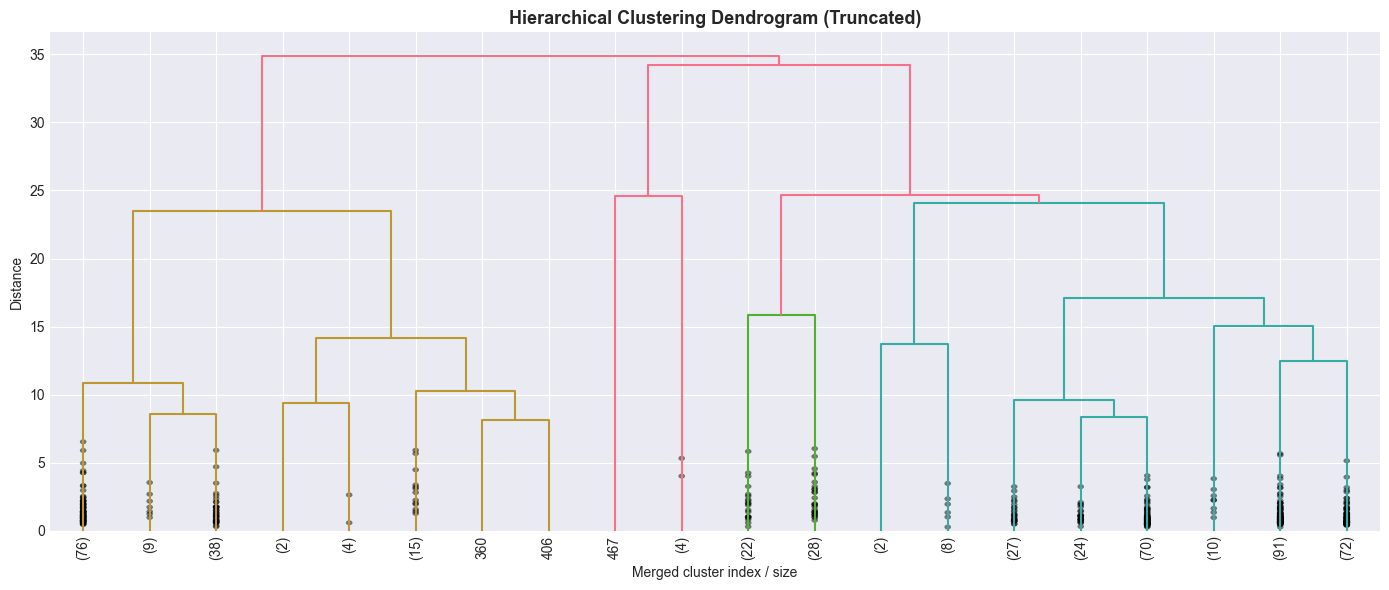

Saved graphs: 02_pca_cluster_scatter.png, 03_hierarchical_dendrogram.png


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=clustering_data['cluster'], cmap='viridis', s=60, alpha=0.8, edgecolor='black'
 )
ax.set_title('K-Means Clusters in PCA Space', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.grid(alpha=0.3)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/02_pca_cluster_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Hierarchical clustering dendrogram (truncated for readability)
linkage_matrix = linkage(X_scaled, method='ward')
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    ax=ax
)
ax.set_title('Hierarchical Clustering Dendrogram (Truncated)', fontsize=13, fontweight='bold')
ax.set_xlabel('Merged cluster index / size')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig(f'{GRAPH_DIR}/03_hierarchical_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved graphs: 02_pca_cluster_scatter.png, 03_hierarchical_dendrogram.png')

## Step 7: Cluster Profile Interpretation (Investment View)

In [17]:
# Build high-level risk labels by volatility quantiles
q1 = clustering_data['volatility'].quantile(0.33)
q2 = clustering_data['volatility'].quantile(0.66)

def risk_label(v):
    if v <= q1:
        return 'Low Risk'
    if v <= q2:
        return 'Medium Risk'
    return 'High Risk'

cluster_risk = clustering_data.groupby('cluster')['volatility'].mean().apply(risk_label)

print('Cluster Interpretation:')
for c in sorted(cluster_summary.index):
    stocks_in_cluster = clustering_data.loc[clustering_data['cluster'] == c, 'Name'].tolist()
    print('\n' + '-'*70)
    print(f'Cluster {c} | Risk Profile: {cluster_risk.loc[c]}')
    print(f'Avg volatility: {cluster_summary.loc[c, "volatility"]:.4f}')
    print(f'Avg return:     {cluster_summary.loc[c, "avg_return"]:.4f}')
    print(f'Avg momentum:   {cluster_summary.loc[c, "momentum"]:.4f}')
    print(f'Stock count:    {len(stocks_in_cluster)}')
    print(f'Sample stocks:  {", ".join(stocks_in_cluster[:12])}')

# Save interpretation helper
cluster_risk.to_csv(f'{DATA_DIR}/cluster_risk_labels.csv', header=['risk_label'])
print('\nSaved CSV: cluster_risk_labels.csv')

Cluster Interpretation:

----------------------------------------------------------------------
Cluster 0 | Risk Profile: Medium Risk
Avg volatility: 0.0154
Avg return:     -0.0021
Avg momentum:   -0.0433
Stock count:    286
Sample stocks:  LKQ, ALLE, AES, WEC, UDR, AMP, ROST, FTV, IP, CVS, COF, PDCO

----------------------------------------------------------------------
Cluster 1 | Risk Profile: High Risk
Avg volatility: 0.0208
Avg return:     0.0021
Avg momentum:   0.0383
Stock count:    139
Sample stocks:  MSI, FLR, FIS, JEC, JPM, BWA, RTN, ABBV, CSRA, VAR, SBAC, EW

----------------------------------------------------------------------
Cluster 2 | Risk Profile: High Risk
Avg volatility: 0.0249
Avg return:     -0.0044
Avg momentum:   -0.0855
Stock count:    4
Sample stocks:  BAC, AMD, GE, F

----------------------------------------------------------------------
Cluster 3 | Risk Profile: High Risk
Avg volatility: 0.0327
Avg return:     -0.0162
Avg momentum:   -0.2864
Stock count:    

In [ ]:
print('Part 3 clustering summary:')
print('optimal_k =', optimal_k)
print('best_k_sil =', best_k_sil, '| best_k_db =', best_k_db)
print('\ncluster_sizes:')
print(cluster_sizes.sort_index())
print('\ncluster_risk:')
print(cluster_risk.sort_index())